C:\Users\10130\AppData\Local\Temp\ipykernel_9028\1901073512.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\10130\AppData\Local\Temp\ipykernel_9028\1901073512.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\10130\AppData\Local\Temp\ipykernel_9028\1901073512.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\10130\AppData\Local\Temp\ipykernel_9028\1901073512.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

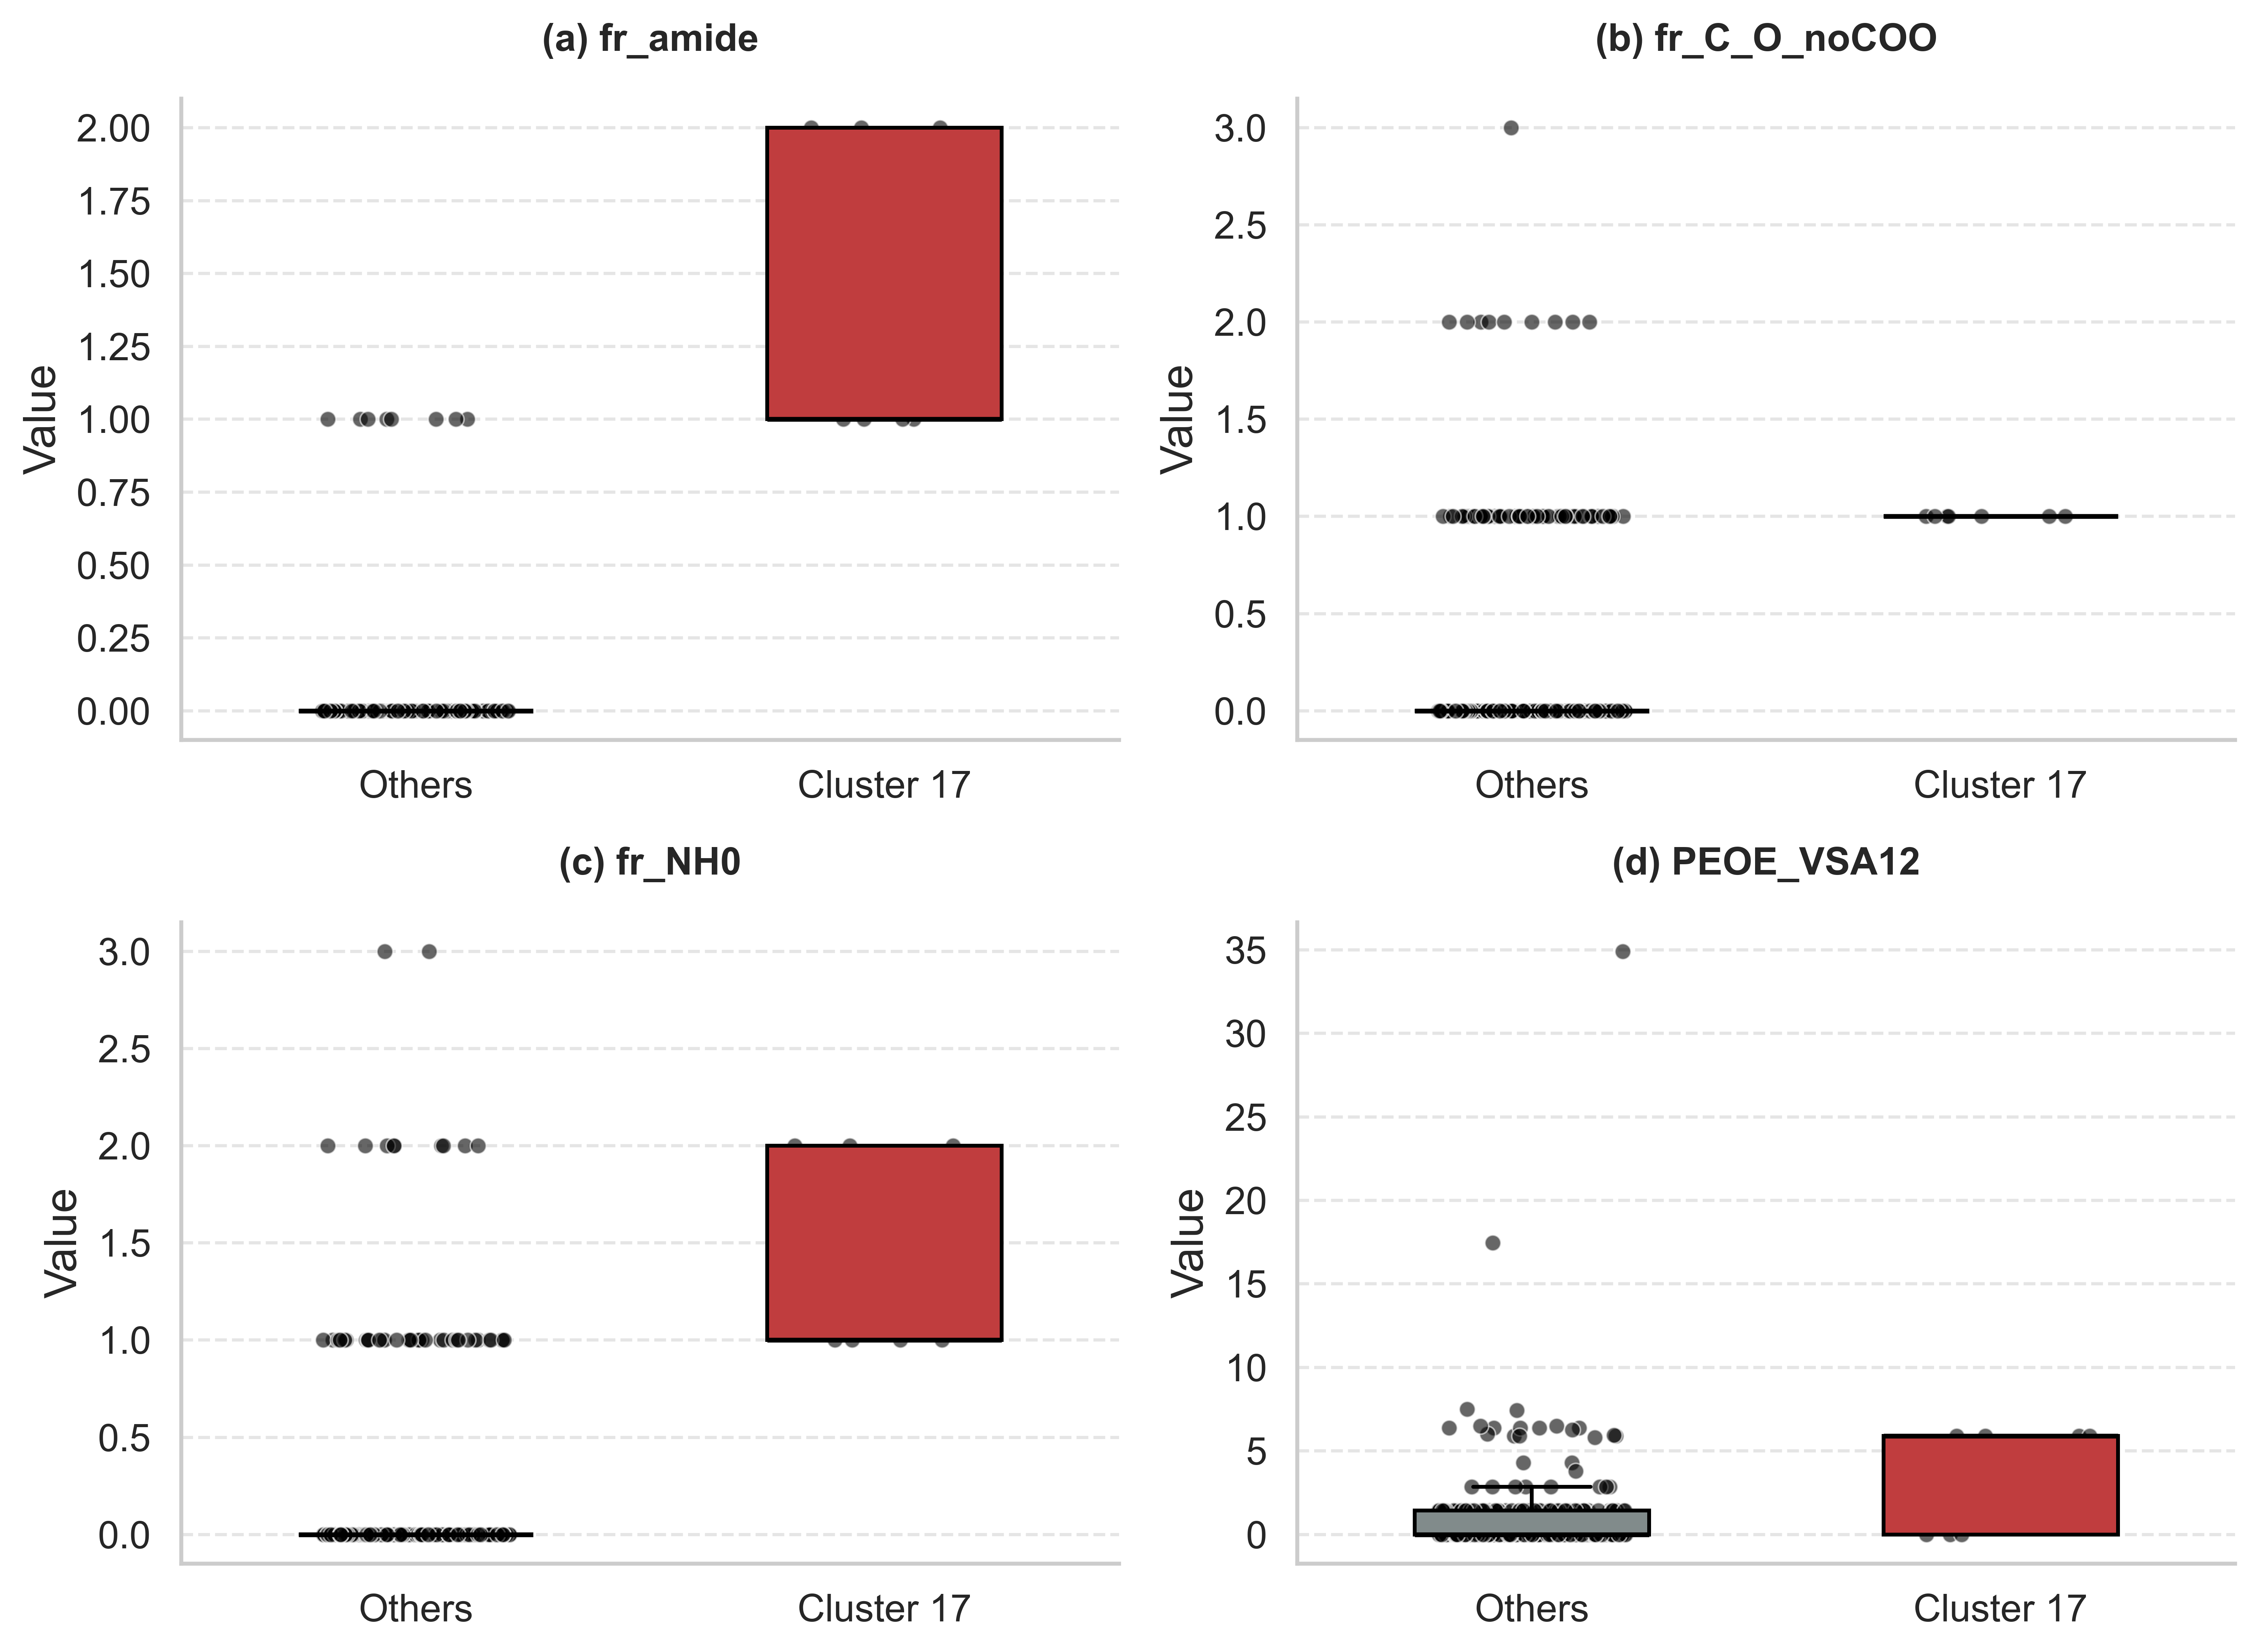

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']
rcParams['axes.labelsize'] = 14      
rcParams['xtick.labelsize'] = 12     
rcParams['ytick.labelsize'] = 12     
rcParams['axes.titlesize'] = 15      
rcParams['legend.fontsize'] = 12     
rcParams['figure.dpi'] = 600         

palette_custom = {
    'Cluster 17': '#D62728',  
    'Others': '#7F8C8D'       
}

# --- 1. Loading data ---
try:
    df_desc = pd.read_csv('solvent.csv')
    df_clusters = pd.read_csv('solvent_clusters.csv')
    df_clusters['Cluster'] = df_clusters['Cluster'].astype(int) + 1
    df_combined = pd.merge(df_desc, df_clusters, on='solvent_smiles')
    
    # --- 2. Data preparation ---
    target_descriptors = ['fr_amide', 'fr_C_O_noCOO', 'fr_NH0', 'PEOE_VSA12']
    df_combined['Group'] = df_combined['Cluster'].apply(lambda x: 'Cluster 17' if x == 17 else 'Others')
    df_combined['Group'] = pd.Categorical(df_combined['Group'], categories=['Others', 'Cluster 17'], ordered=True)

except FileNotFoundError as e:
    print(f"Error: {e}")

# --- 3. Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

sns.set_theme(style="whitegrid", rc={"grid.linestyle": "--", "grid.alpha": 0.5})

for i, desc in enumerate(target_descriptors):
    ax = axes[i]
    
    # A. Boxplot
    sns.boxplot(
        data=df_combined, 
        x='Group', 
        y=desc, 
        ax=ax,
        palette=palette_custom,
        width=0.5, 
        showfliers=False, 
        boxprops=dict(edgecolor="black", linewidth=1.2), 
        medianprops=dict(color="black", linewidth=1.5),  
        whiskerprops=dict(color="black", linewidth=1.2),
        capprops=dict(color="black", linewidth=1.2)
    )
    
    # B. scatter points
    sns.stripplot(
        data=df_combined, 
        x='Group', 
        y=desc, 
        ax=ax,
        color="black", 
        size=5, 
        alpha=0.6, 
        edgecolor="white", 
        linewidth=0.5,
        jitter=0.2, 
        zorder=1    
    )
    
    nice_name = desc
    ax.set_title(f'({chr(97+i)}) {nice_name}', pad=15, fontweight='bold')
    
    ax.set_xlabel('') 
    ax.set_ylabel('Value') 
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
    ax.ticklabel_format(axis='y', style='plain', scilimits=(0,0)) 

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('Key_Descriptors_Boxplot.png', bbox_inches='tight', dpi=600)
plt.show()

In [ ]:
import pandas as pd

# Load data
df_desc = pd.read_csv('solvent.csv')
df_clusters = pd.read_csv('solvent_clusters.csv')
df_combined = pd.merge(df_desc, df_clusters, on='solvent_smiles')

# Select target descriptors for comparison
target_descriptors = ['fr_amide', 'fr_C_O_noCOO', 'fr_NH0', 'PEOE_VSA12']

# 1. Global
global_means = df_combined[target_descriptors].mean()

# 2. Cluster 17
c16_data = df_combined[df_combined['Cluster'] == 16][target_descriptors]
c16_means = c16_data.mean()

# 3. Deviation calculation
deviation = ((c16_means - global_means) / global_means.abs()) * 100

# 4. Create comparison table
comparison_table = pd.DataFrame({
    'Descriptor': target_descriptors,
    'Global Mean': global_means.values,
    'Cluster 16 Mean': c16_means.values,
    'Deviation (%)': deviation.values
})


print("--- Comparison Table for Supplementary Information ---")
print(comparison_table.round(4).to_string(index=False))
comparison_table.to_csv('Descriptor_Comparison_Table.csv', index=False)

--- Comparison Table for Supplementary Information ---
  Descriptor  Global Mean  Cluster 16 Mean  Deviation (%)
    fr_amide       0.0517           1.4286      2661.9048
fr_C_O_noCOO       0.2730           1.0000       266.3158
      fr_NH0       0.1925           1.4286       642.0043
  PEOE_VSA12       0.8503           3.3755       296.9581
